<a href="https://colab.research.google.com/github/Renadyousef/SWE485-Project-Group1/blob/main/NeuralNetwork_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving feature_data.joblib to feature_data.joblib
Data loaded
X shape: (39139, 5015)
y shape: (39139,)
Train: (31311, 5015)  Test: (7828, 5015)
Training MLP model...
Model trained
Accuracy: 99.86 %

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3462
           1       1.00      1.00      1.00      4366

    accuracy                           1.00      7828
   macro avg       1.00      1.00      1.00      7828
weighted avg       1.00      1.00      1.00      7828



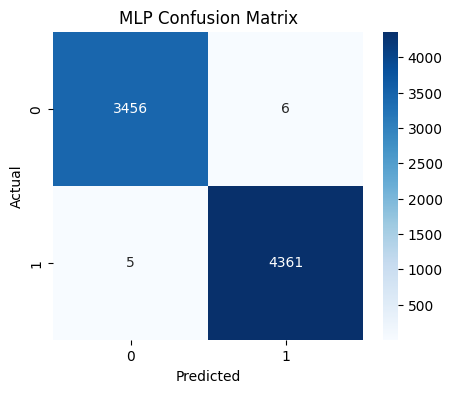

In [1]:
# Step 1: install and import libraries
!pip install joblib scikit-learn seaborn matplotlib

import joblib
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: upload the prepared dataset
from google.colab import files
uploaded = files.upload()

data = joblib.load("feature_data.joblib")

X = data["X"]
y = data["y"]

print("Data loaded")
print("X shape:", X.shape)
print("y shape:", y.shape)

# Step 3: split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

# Step 4: train the neural network model
# I used 2 hidden layers (128 and 64) and relu activation
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=30,
    random_state=42
)

print("Training MLP model...")
mlp.fit(X_train, y_train)
print("Model trained")

# Step 5: evaluate the model
y_pred = mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
